In [13]:
import json
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
import datetime
import re

# Configuration
RESULTS_DIR = Path("../results")


In [14]:
%matplotlib widget

In [15]:
# Enter the filename to load (without path, or with full path)
filename = "results/2026/01/08/full_swing_20260108-182744.json"  # Change this to your filename

# Construct full path
if Path(filename).is_absolute():
    filepath = Path(filename)
else:
    # Extract date from filename (format: prefix_YYYYMMDD-HHMMSS.json)
    # Extract just the filename without directory if provided
    filename_only = Path(filename).name
    
    # Try to extract date from filename pattern: *_YYYYMMDD-*.json
    match = re.search(r'_(\d{8})-', filename_only)
    if match:
        date_str = match.group(1)  # YYYYMMDD
        year = date_str[:4]
        month = date_str[4:6]
        day = date_str[6:8]
        # Construct hierarchical path: results/YYYY/MM/DD/filename
        filepath = RESULTS_DIR / year / month / day / filename_only
    else:
        # Fallback: if date pattern not found, try direct path
        filepath = RESULTS_DIR / filename_only
        print(f"Warning: Could not extract date from filename. Using direct path.")

print(f"Loading data from: {filepath}")


Loading data from: ../results/2026/01/08/full_swing_20260108-182744.json


In [16]:
# Load the JSON data
with open(filepath, 'r') as f:
    data = json.load(f)

# Display metadata
print(f"Measurement timestamp: {data['timestamp']}")
print(f"Measurement time: {data['measurement_time']}")
if 'sec_utc' in data:
    dt = datetime.datetime.fromtimestamp(data['sec_utc'])
    print(f"UTC time: {dt.strftime('%Y-%m-%d %H:%M:%S UTC')}")
print(f"Sample rate: {data['sample_rate_hz']} Hz")
print(f"Duration: {data['measurement_duration_s']} s")
print(f"Buffer size: {data['buffer_size']} samples")
print(f"Channel range: ±{data['channel_range_v']} V")
print(f"Number of voltage samples: {len(data['voltage_data_v'])}")
print(f"Number of time samples: {len(data['time_s'])}")


Measurement timestamp: 20260108-182744
Measurement time: 2026-01-08 18:27:44
UTC time: 2026-01-08 18:27:44 UTC
Sample rate: 10000000.0 Hz
Duration: 0.001 s
Buffer size: 10001 samples
Channel range: ±0.5 V
Number of voltage samples: 10001
Number of time samples: 10001


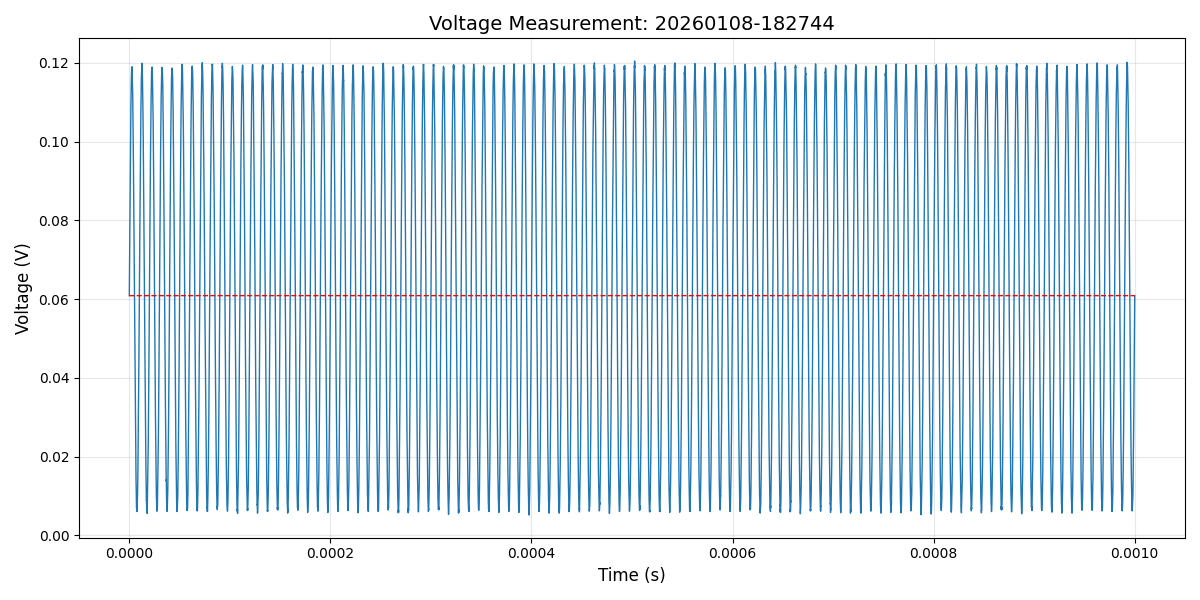


Voltage Statistics:
  Min: 0.005184 V
  Max: 0.120433 V
  Mean: 0.062727 V
  Std: 0.039921 V


In [ ]:
# Extract data arrays
time_s = np.array(data['time_s'])  # Time in seconds
voltage_pd_1 = np.array(data['voltage_pd_1'])  # Voltage in Volts
voltage_pd_2 = np.array(data['voltage_pd_2'])  # Voltage in Volts

# Plot voltage vs time
plt.figure(figsize=(12, 6))
plt.plot(time_s, voltage_pd_1,linewidth=1)
plt.plot(time_s, voltage_pd_2,linewidth=1)
plt.plot(time_s, np.min(voltage_pd_1[0])*np.ones(len(time_s)), 'r--', linewidth=1)  # Zero line
plt.xlabel('Time (s)', fontsize=12)
plt.ylabel('Voltage (V)', fontsize=12)
plt.title(f'Voltage Measurement: {data["timestamp"]}', fontsize=14)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Print statistics
print(f"\nVoltage Statistics:")
print(f"  Min: {np.min(voltage_pd_1):.6f} V")
print(f"  Max: {np.max(voltage_pd_1):.6f} V")
print(f"  Mean: {np.mean(voltage_pd_1):.6f} V")
print(f"  Std: {np.std(voltage_pd_1):.6f} V")
